# T2 — Time to Calibrate: Pressure Time Series

Interactive time series showing heel and toe pressure for each foot.
Use the dropdown(s) to switch between participants.

## Study phase context

**T2** investigated how long participants needed to stand still for the pressure insole to produce a stable calibration baseline. Eight participants performed a resting calibration phase of varying durations. The results informed the fixed calibration window used in later trials.

This phase directly shaped the calibration protocol used in T3 and the final study (T6).

In [43]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
DATA_DIR = Path(".")

In [44]:
def parse_pressure_file(path):
    """Parse any semicolon-delimited pressure CSV into time_s, L_toe, L_heel, R_toe, R_heel."""
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    raw = path.read_bytes()
    data = raw.replace(b"\r\n", b"\n").replace(b"\r", b"\n").decode("utf-8", errors="replace")
    records = [r.strip() for r in data.split(";") if r.strip()]
    rows = []
    for rec in records:
        rec = re.sub(r"^\d+,\s*", "", rec)   # strip leading index field
        nums = re.findall(r"[\d]+\.?[\d]*", rec)
        if len(nums) < 5:
            continue
        try:
            ts = float(nums[0])
            sensors = [float(n) for n in nums[1:] if float(n) <= 1023]
            if len(sensors) < 4:
                continue
            rows.append({"ts_ms": ts, "L_toe": sensors[0], "L_heel": sensors[1],
                         "R_toe": sensors[2], "R_heel": sensors[3]})
        except ValueError:
            continue
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["time_s"] = (df["ts_ms"] - df["ts_ms"].iloc[0]) / 1000.0
    return df


def parse_imu_pressure_file(path):
    """Parse IMU-derived pressure_from_imu.csv (device_ms,toe_L,heel_L,toe_R,heel_R)."""
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df = df.rename(columns={"toe_L": "L_toe", "heel_L": "L_heel",
                             "toe_R": "R_toe", "heel_R": "R_heel"})
    for col in ["L_toe", "L_heel", "R_toe", "R_heel"]:
        if col not in df.columns:
            df[col] = float("nan")
    df = df.dropna(subset=["device_ms"]).reset_index(drop=True)
    df["time_s"] = (df["device_ms"] - df["device_ms"].iloc[0]) / 1000.0
    return df

In [45]:
def plot_pressure(df, title=""):
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    fig.subplots_adjust(hspace=0.38)
    TOE_COLOR  = "#2ecc71"
    HEEL_COLOR = "#e74c3c"
    for ax, (foot, toe_col, heel_col) in zip(axes, [
        ("Left",  "L_toe", "L_heel"),
        ("Right", "R_toe", "R_heel"),
    ]):
        if df is None or df.empty or toe_col not in df.columns:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center",
                    transform=ax.transAxes, fontsize=11, color="gray")
            ax.set_title(f"{foot} foot", fontsize=10)
            continue
        ax.plot(df["time_s"], df[toe_col],  color=TOE_COLOR,  lw=0.9,
                label=f"{foot} toe",  alpha=0.85)
        ax.plot(df["time_s"], df[heel_col], color=HEEL_COLOR, lw=0.9,
                label=f"{foot} heel", alpha=0.85)
        ax.set_ylabel("Pressure (ADC)", fontsize=9)
        ax.set_title(f"{foot} foot", fontsize=10)
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(linestyle="--", alpha=0.35)
    axes[-1].set_xlabel("Time (s)", fontsize=10)
    fig.suptitle(title, fontsize=11, y=1.01)
    plt.show()

## Participant / data discovery

In [46]:
EXCLUDED = {"excluded data"}
participants = sorted([
    d.name for d in DATA_DIR.iterdir()
    if d.is_dir() and d.name not in EXCLUDED
])
print(f"Participants: {participants}")

Participants: ['.claude', '.ipynb_checkpoints', '01', '02', '03', '04', '06', '07', '08', '09', 'figures']


## Interactive time series

In [47]:
def load_data_t2(pid, _=None):
    pid_dir = DATA_DIR / pid
    files = sorted(pid_dir.glob("*.csv"))
    if not files:
        return pd.DataFrame()
    dfs = []
    offset_ms = 0.0
    for f in files:
        df = parse_pressure_file(f)
        if df.empty:
            continue
        # chain files end-to-end with a 1-second gap
        df["ts_ms"] += offset_ms
        offset_ms = df["ts_ms"].iloc[-1] + 1000.0
        dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    combined = pd.concat(dfs, ignore_index=True)
    combined["time_s"] = (combined["ts_ms"] - combined["ts_ms"].iloc[0]) / 1000.0
    return combined

selector = widgets.Dropdown(
    options=participants, value=participants[0] if participants else None,
    description="Participant:",
    style={"description_width": "90px"},
    layout=widgets.Layout(width="200px"),
)
out = widgets.Output()

def on_change(change):
    out.clear_output(wait=True)
    with out:
        df = load_data_t2(selector.value)
        plot_pressure(df, title=f"T2 — Participant {selector.value}")

selector.observe(on_change, names="value")
display(widgets.HBox([selector]), out)
with out:
    df = load_data_t2(selector.value)
    plot_pressure(df, title=f"T2 — Participant {selector.value}")

Output()

## Why 30 s? Calibration Convergence Analysis

Each test session contains **three ~10 s recordings** and **one ~30 s recording**. The 30 s file is the calibration reference — the long recording from which a stable baseline pressure is derived for each sensor channel.

Three complementary analyses below justify why 10 s is insufficient:

1. **Raw signal** — the 30 s trace shows the sensor output is still settling through the first 10 s.  
2. **Cumulative mean ± 95 % CI** — the running estimate of the calibration value narrows substantially between 10 s and 30 s.  
3. **Calibration error vs window length** — truncating the recording early introduces a systematic bias in the calibration value; the error drops below 1 % only around 20–30 s.

In [48]:
# ── helpers for calibration analysis ──────────────────────────────────────────

DROPOUT_THRESHOLD = 1.0   # ADC values below this are sensor glitches
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=150, bbox_inches="tight")
    print(f"Saved → figures/{name}.png  |  figures/{name}.pdf")

def classify_files(pid):
    """Return (short_files, long_file) for a participant; long = duration > 20 s."""
    pid_dir = DATA_DIR / pid
    short, long = [], None
    for f in sorted(pid_dir.glob("*.csv")):
        df = parse_pressure_file(f)
        if df.empty:
            continue
        dur = df["time_s"].iloc[-1]
        if dur > 20:
            long = (f, df)
        else:
            short.append((f, df))
    return short, long


def clean(df):
    """Remove dropout rows (any sensor reading < DROPOUT_THRESHOLD)."""
    cols = ["L_toe", "L_heel", "R_toe", "R_heel"]
    mask = (df[cols] > DROPOUT_THRESHOLD).all(axis=1)
    return df[mask].reset_index(drop=True)


# Load 30-s calibration data for every participant
calib_data = {}   # pid → clean DataFrame
for pid in participants:
    _, long_info = classify_files(pid)
    if long_info is None:
        continue
    _, df_long = long_info
    calib_data[pid] = clean(df_long)

print(f"Loaded 30-s calibration data for {len(calib_data)} participants: {list(calib_data)}")
print(f"Figures will be saved to: {FIG_DIR.resolve()}")

Loaded 30-s calibration data for 8 participants: ['01', '02', '03', '04', '06', '07', '08', '09']
Figures will be saved to: /Users/zoe/Library/CloudStorage/OneDrive-Personal/University/year4/Masters/Final Submission Data analysis/t2_timetocalibrate/figures


Saved → figures/fig1_raw_30s_signal.png  |  figures/fig1_raw_30s_signal.pdf


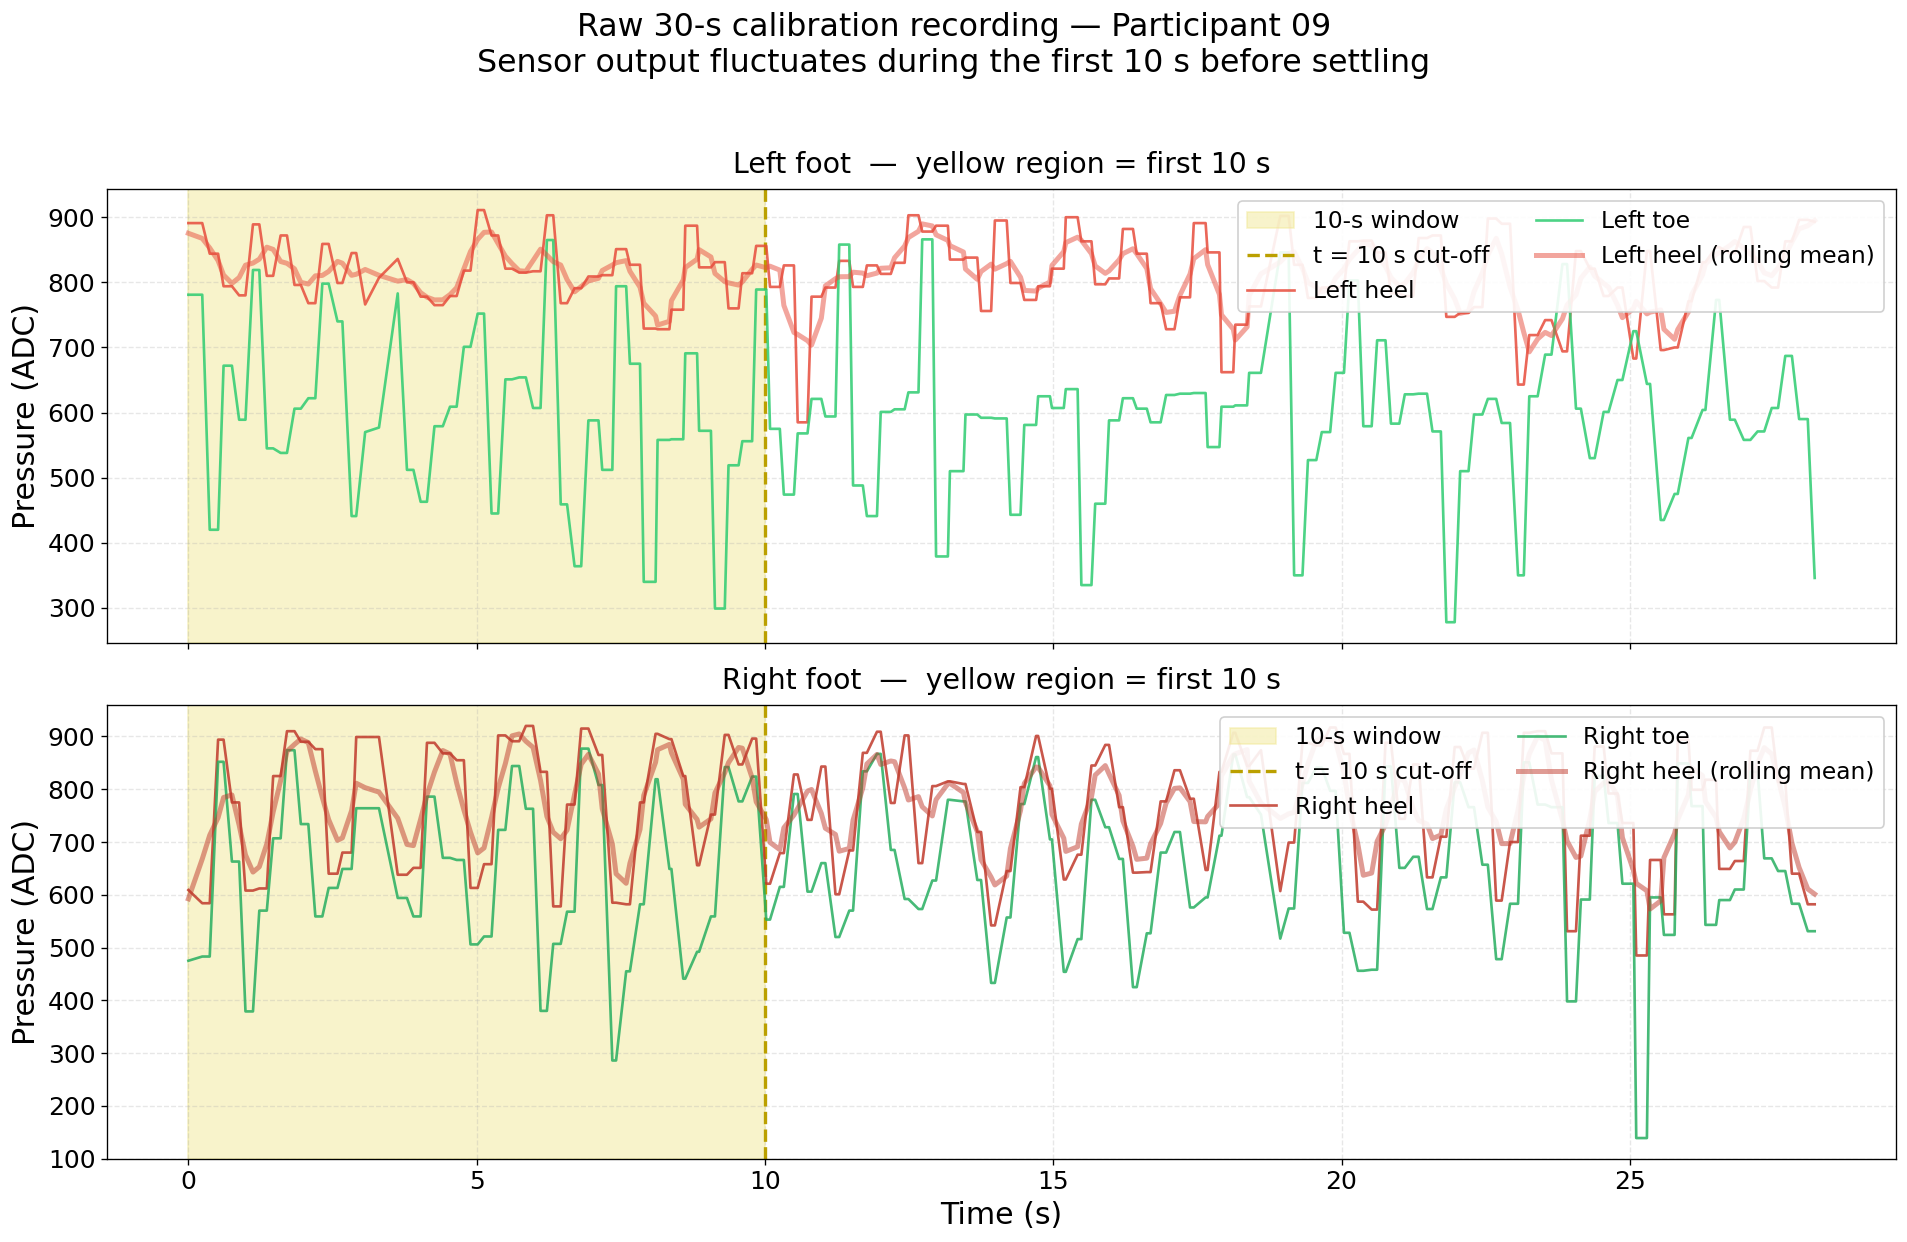

In [49]:
# ── Figure 1: raw 30-s signal for an example participant ──────────────────────
def make_fig1():
    EXAMPLE_PID = "09"
    df_ex = calib_data[EXAMPLE_PID]
    CUTOFF = 10.0

    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    fig.subplots_adjust(hspace=0.55)

    for ax, (foot, heel_col, toe_col, color_h, color_t) in zip(axes, [
        ("Left",  "L_heel", "L_toe",  "#e74c3c", "#2ecc71"),
        ("Right", "R_heel", "R_toe",  "#c0392b", "#27ae60"),
    ]):
        ax.axvspan(0, CUTOFF, color="#f0e68c", alpha=0.45, label="10-s window")
        ax.axvline(CUTOFF, color="#bba000", lw=2.0, ls="--", label=f"t = {CUTOFF:.0f} s cut-off")
        ax.plot(df_ex["time_s"], df_ex[heel_col], color=color_h, lw=1.6, alpha=0.85, label=f"{foot} heel")
        ax.plot(df_ex["time_s"], df_ex[toe_col],  color=color_t, lw=1.6, alpha=0.85, label=f"{foot} toe")
        roll = df_ex[heel_col].rolling(5, center=True, min_periods=1).mean()
        ax.plot(df_ex["time_s"], roll, color=color_h, lw=3.0, ls="-", alpha=0.5, label=f"{foot} heel (rolling mean)")
        ax.set_ylabel("Pressure (ADC)", fontsize=18)
        ax.set_title(f"{foot} foot  —  yellow region = first {CUTOFF:.0f} s", fontsize=17, pad=10)
        ax.legend(fontsize=14, loc="upper right", ncol=2, framealpha=0.9)
        ax.tick_params(labelsize=15)
        ax.grid(linestyle="--", alpha=0.3)

    axes[-1].set_xlabel("Time (s)", fontsize=18)
    fig.suptitle(
        f"Raw 30-s calibration recording — Participant {EXAMPLE_PID}\n"
        "Sensor output fluctuates during the first 10 s before settling",
        fontsize=19, y=1.03,
    )
    plt.tight_layout()
    return fig

fig1 = make_fig1()
save_fig(fig1, "fig1_raw_30s_signal")
plt.show()

**Figure 1.** Raw ADC pressure readings from the heel and toe sensors of one representative participant over the full 30-second calibration recording. The highlighted region shows that within the first 10 seconds the signal has not yet settled into a stable range, with the rolling mean still visibly drifting — indicating that a 10-second window alone would not capture a reliable baseline.

Saved → figures/fig2_cumulative_mean_ci.png  |  figures/fig2_cumulative_mean_ci.pdf


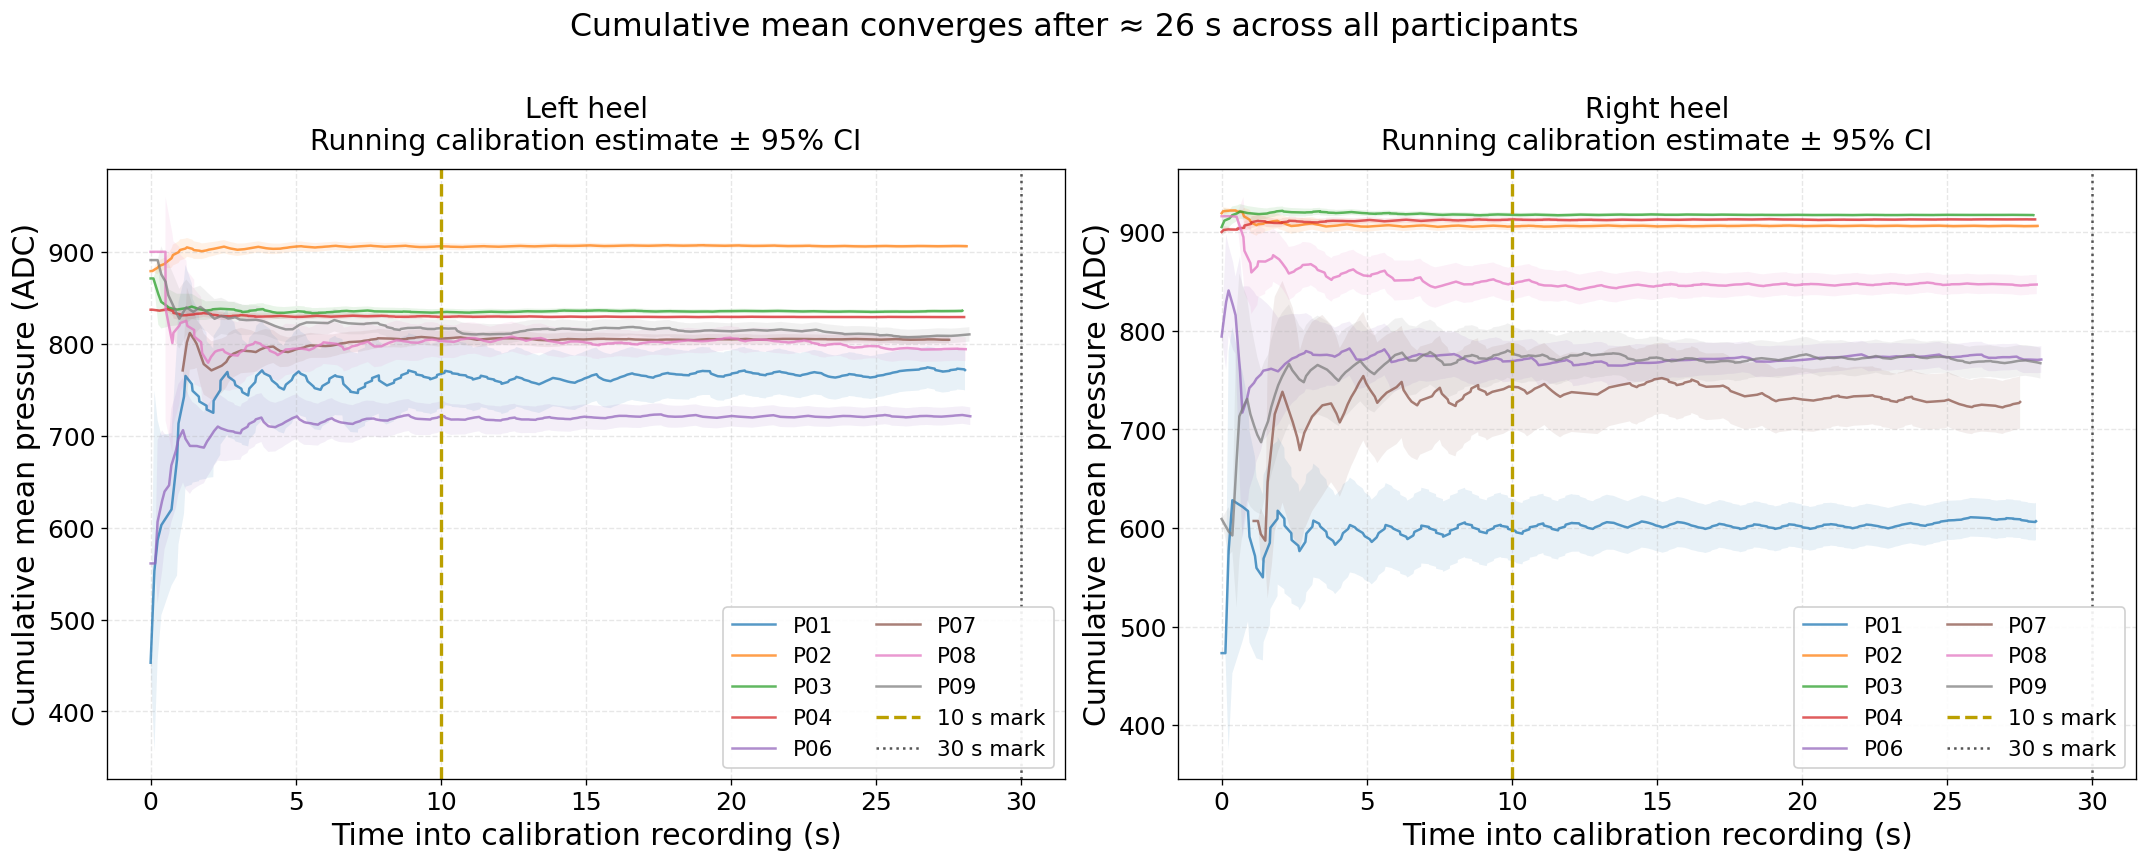

In [50]:
# ── Figure 2: cumulative mean ± 95 % CI for all participants ──────────────────
def make_fig2():
    SENSORS = [("L_heel", "#e74c3c", "Left heel"),
               ("R_heel", "#2980b9", "Right heel")]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)
    fig.subplots_adjust(wspace=0.42)

    for ax, (col, color, label) in zip(axes, SENSORS):
        for pid, df in calib_data.items():
            vals = df[col].values.astype(float)
            n        = np.arange(1, len(vals) + 1)
            cum_mean = np.cumsum(vals) / n
            cum_sem  = np.array([
                vals[:i].std(ddof=1) / np.sqrt(i) if i > 1 else 0.0
                for i in n
            ])
            ci95 = 1.96 * cum_sem
            ax.plot(df["time_s"].values, cum_mean, lw=1.5, alpha=0.75, label=f"P{pid}")
            ax.fill_between(df["time_s"].values, cum_mean - ci95, cum_mean + ci95, alpha=0.10)

        ax.axvline(10, color="#bba000", lw=2.0, ls="--", label="10 s mark")
        ax.axvline(30, color="#555",    lw=1.5, ls=":",  label="30 s mark")
        ax.set_xlabel("Time into calibration recording (s)", fontsize=18)
        ax.set_ylabel("Cumulative mean pressure (ADC)", fontsize=18)
        ax.set_title(f"{label}\nRunning calibration estimate ± 95% CI", fontsize=17, pad=12)
        ax.legend(fontsize=13, ncol=2, loc="lower right", framealpha=0.9)
        ax.tick_params(labelsize=15)
        ax.grid(linestyle="--", alpha=0.3)

    fig.suptitle(
        "Cumulative mean converges after ≈ 26 s across all participants",
        fontsize=19, y=1.02,
    )
    plt.tight_layout()
    return fig

fig2 = make_fig2()
save_fig(fig2, "fig2_cumulative_mean_ci")
plt.show()

**Figure 2.** Cumulative mean pressure (ADC) and 95% confidence interval for each participant's 30-second calibration recording, shown for the left and right heel channels. The confidence band narrows substantially between 10 and 30 seconds, reflecting the reduction in statistical uncertainty as more samples are included — the estimate is still unstable at the 10-second mark across most participants.

Saved → figures/fig3_calibration_error_vs_window.png  |  figures/fig3_calibration_error_vs_window.pdf


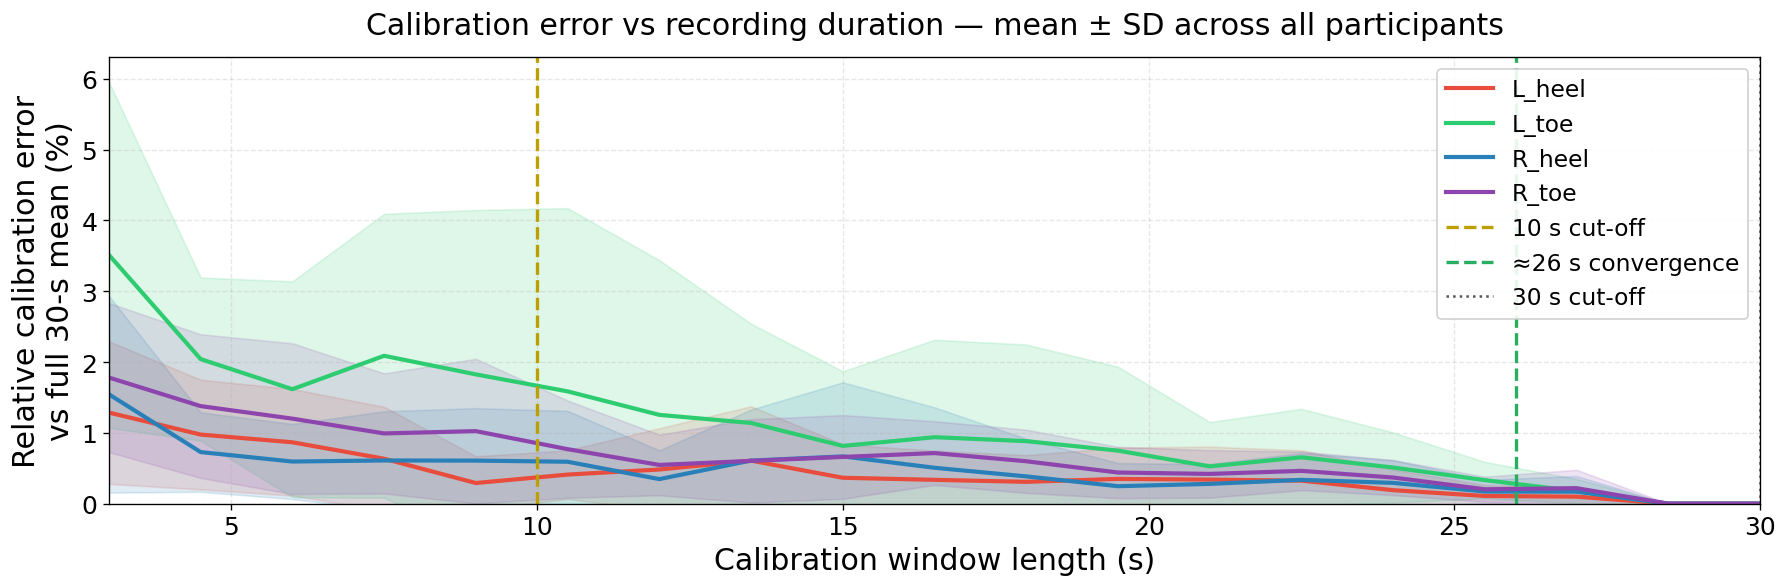


Mean relative calibration error (%) at key window lengths:

     5 s : 1.28 %
    10 s : 0.84 %
    15 s : 0.63 %
    20 s : 0.45 %
    25 s : 0.20 %
    30 s : 0.00 %


In [51]:
# ── Figure 3: calibration error vs window length ──────────────────────────────
def make_fig3():
    DURATIONS  = np.arange(3, 31, 1.5)
    CALIB_COLS = ["L_heel", "R_heel", "L_toe", "R_toe"]

    records = []
    for pid, df in calib_data.items():
        full_means = {c: df[c].mean() for c in CALIB_COLS}
        for d in DURATIONS:
            window = df[df["time_s"] <= d]
            if len(window) < 3:
                continue
            for c in CALIB_COLS:
                if full_means[c] == 0:
                    continue
                err = abs(window[c].mean() - full_means[c]) / full_means[c] * 100.0
                records.append({"pid": pid, "duration": d, "sensor": c, "error_pct": err})

    err_df  = pd.DataFrame(records)
    summary = err_df.groupby(["duration", "sensor"])["error_pct"].agg(["mean", "std"]).reset_index()

    fig, ax = plt.subplots(figsize=(15, 5))
    palette = {"L_heel": "#e74c3c", "R_heel": "#2980b9", "L_toe": "#2ecc71", "R_toe": "#8e44ad"}

    for sensor, grp in summary.groupby("sensor"):
        color = palette[sensor]
        ax.plot(grp["duration"], grp["mean"], color=color, lw=2.5, label=sensor)
        ax.fill_between(grp["duration"], grp["mean"] - grp["std"], grp["mean"] + grp["std"],
                        color=color, alpha=0.15)

    ax.axvline(10, color="#bba000", lw=2.0, ls="--", label="10 s cut-off")
    ax.axvline(26, color="#27ae60", lw=2.0, ls="--", label="≈26 s convergence")
    ax.axvline(30, color="#555",    lw=1.5, ls=":",  label="30 s cut-off")
    ax.set_xlabel("Calibration window length (s)", fontsize=18)
    ax.set_ylabel("Relative calibration error\nvs full 30-s mean (%)", fontsize=18)
    ax.set_title(
        "Calibration error vs recording duration — mean ± SD across all participants",
        fontsize=18, pad=14,
    )
    ax.legend(fontsize=14, loc="upper right", framealpha=0.9)
    ax.set_xlim(DURATIONS[0], DURATIONS[-1])
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=15)
    ax.grid(linestyle="--", alpha=0.3)
    plt.tight_layout()
    return fig, err_df

fig3, err_df = make_fig3()
save_fig(fig3, "fig3_calibration_error_vs_window")
plt.show()

print("\nMean relative calibration error (%) at key window lengths:\n")
pivot = (err_df.groupby("duration")["error_pct"].mean().reset_index()
         .rename(columns={"error_pct": "mean_error_%"}))
for d in [5, 10, 15, 20, 25, 30]:
    row = pivot[np.isclose(pivot["duration"], d, atol=0.8)]
    if not row.empty:
        print(f"  {d:4.0f} s : {row['mean_error_%'].values[0]:.2f} %")

**Figure 3.** Mean relative error of the calibration baseline (compared to the full 30-second mean) as a function of recording duration, averaged across all participants and sensor channels (± SD shaded). Error decreases monotonically with window length, falling from ~0.84% at 10 seconds to near zero by 30 seconds — supporting 30 seconds as the minimum duration needed to obtain a stable calibration reference. Note that the 30-second recording is used as its own reference here; the 1% threshold line is indicative rather than externally validated.

In [52]:
# ── Export buttons ─────────────────────────────────────────────────────────────
def make_export_btn(label, make_fn, fname):
    btn = widgets.Button(
        description=label,
        button_style="primary",
        layout=widgets.Layout(width="200px", height="36px"),
    )
    status = widgets.Label(value="")

    def on_click(_):
        status.value = "Saving…"
        fig = make_fn()
        save_fig(fig, fname)
        plt.close(fig)
        status.value = f"✓ Saved to figures/{fname}.png/.pdf"

    btn.on_click(on_click)
    return widgets.HBox([btn, status])

# make_fig3 returns (fig, df) so wrap it
display(
    widgets.VBox([
        make_export_btn("Export Fig 1", make_fig1, "fig1_raw_30s_signal"),
        make_export_btn("Export Fig 2", make_fig2, "fig2_cumulative_mean_ci"),
        make_export_btn("Export Fig 3", lambda: make_fig3()[0], "fig3_calibration_error_vs_window"),
    ])
)